In [ ]:
# conda create -n myenv python=3.11 --> make sure to create this kind of kernel for the notebook
# then from CLI --> 'conda activate myenv' --> pip install ipykernel. Then run the notebook


! pip install numpy matplotlib==3.8.2 jupyter jupyterlab_nvdashboard jupyterlab tqdm scikit-image==0.22.0 accelerate==0.24.1 webdataset==0.2.73 pandas==2.2.0 einops ftfy regex kornia==0.7.1 h5py==3.10.0 open_clip_torch==2.24.0 torchvision==0.16.0 torch==2.1.0 transformers==4.37.2 xformers==0.0.22.post7 torchmetrics==1.3.0.post0 diffusers==0.23.0 deepspeed==0.13.1 wandb omegaconf==2.3.0 pytorch-lightning==2.0.1 sentence-transformers==2.5.1 evaluate==0.4.1 nltk==3.8.1 rouge_score==0.1.2 umap-learn==0.1.1
! pip install git+https://github.com/openai/CLIP.git --no-deps
! pip install dalle2-pytorch
! pip install setuptools==69.5.1
! pip install huggingface-hub==0.19.4 datasets==2.14.7

  Using cached torchvision-0.16.0-cp311-cp311-manylinux1_x86_64.whl.metadata (6.6 kB)
  Using cached torch-2.1.0-cp311-cp311-manylinux1_x86_64.whl.metadata (25 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.met

In [ ]:
# # Uncomment ONCE just to download the necessary files

# ! mkdir -p datasets
# ! wget -O datasets/coco_images_224_float16.hdf5 https://huggingface.co/datasets/pscotti/mindeyev2/resolve/main/coco_images_224_float16.hdf5
# ! wget -O datasets/unclip6_epoch0_step110000.ckpt https://huggingface.co/datasets/pscotti/mindeyev2/resolve/main/unclip6_epoch0_step110000.ckpt
# ! wget -O datasets/betas_all_subj01_fp32_renorm.hdf5 https://huggingface.co/datasets/pscotti/mindeyev2/resolve/main/betas_all_subj01_fp32_renorm.hdf5
# ! wget -O datasets/sd_image_var_autoenc.pth https://huggingface.co/datasets/pscotti/mindeyev2/resolve/main/sd_image_var_autoenc.pth
# ! wget -O datasets/bigG_to_L_epoch8.pth https://huggingface.co/datasets/pscotti/mindeyev2/resolve/main/bigG_to_L_epoch8.pth
# ! mkdir -p train_logs/final_subj01_pretrained_40sess_24bs
# ! wget -O train_logs/final_subj01_pretrained_40sess_24bs/last.pth https://huggingface.co/datasets/pscotti/mindeyev2/resolve/main/train_logs/final_subj01_pretrained_40sess_24bs/last.pth
# ! mkdir -p datasets/wds/subj01/new_test
# ! wget -O datasets/wds/subj01/new_test/0.tar https://huggingface.co/datasets/pscotti/mindeyev2/resolve/main/wds/subj01/new_test/0.tar




In [3]:
! pip install --pre torch torchvision --index-url https://download.pytorch.org/whl/nightly/cu128 --upgrade

Looking in indexes: https://download.pytorch.org/whl/nightly/cu128
  Using cached https://download-r2.pytorch.org/whl/nightly/cu128/torch-2.12.0.dev20260408%2Bcu128-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached https://download-r2.pytorch.org/whl/nightly/cu128/torchvision-0.27.0.dev20260407%2Bcu128-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.9/657.9 MB 71.5 MB/s  0:00:09:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 69.1 MB/s  0:00:04:00:0100:01
  Using cached https://download-r2.pytorch.org/whl/nightly/triton-3.7.0%2Bgit282c8251-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.7 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 69.3 MB/s  0:00:08:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 20.8 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 91.8 MB/s  0:00:02ta 0:00:01
     ━━━━━━━━

In [5]:
import os
import sys
import json
import argparse
import numpy as np
import math
from einops import rearrange
import time
import random
import string
import h5py
from tqdm import tqdm
import webdataset as wds

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from accelerate import Accelerator

# SDXL unCLIP requires code from https://github.com/Stability-AI/generative-models/tree/main
sys.path.append('generative_models/')
import sgm
from generative_models.sgm.modules.encoders.modules import FrozenOpenCLIPImageEmbedder, FrozenOpenCLIPEmbedder2
from generative_models.sgm.models.diffusion import DiffusionEngine
from generative_models.sgm.util import append_dims
from omegaconf import OmegaConf



# tf32 data type is faster than standard float32
torch.backends.cuda.matmul.allow_tf32 = True

# custom functions #
import utils
from models import *

accelerator = Accelerator(split_batches=False, mixed_precision="fp16")
device = accelerator.device
print("device:",device)

/home/alessia/miniconda3/envs/mindenv/lib/python3.11/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/home/alessia/miniconda3/envs/mindenv/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.1.0+cu121 with CUDA 1201 (you have 2.12.0.dev20260407+cu128)
    Python  3.11.6 (you have 3.11.15)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for 

device: cuda


/home/alessia/miniconda3/envs/mindenv/lib/python3.11/site-packages/accelerate/accelerator.py:439: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [6]:
# if running this interactively, can specify jupyter_args here for argparser to use
if utils.is_interactive():
    model_name = "final_subj01_pretrained_40sess_24bs"
    print("model_name:", model_name)

    path = "datasets"

    # other variables can be specified in the following string:
    jupyter_args = f"--data_path={path} \
                    --cache_dir={path} \
                    --model_name={model_name} --subj=1 \
                    --hidden_dim=4096 --n_blocks=4 --new_test"
    print(jupyter_args)
    jupyter_args = jupyter_args.split()
    
    from IPython.display import clear_output # function to clear print outputs in cell
    %load_ext autoreload 
    # this allows you to change functions in models.py or utils.py and have this notebook automatically update with your revisions
    %autoreload 2 

model_name: final_subj01_pretrained_40sess_24bs
--data_path=datasets                     --cache_dir=datasets                     --model_name=final_subj01_pretrained_40sess_24bs --subj=1                     --hidden_dim=4096 --n_blocks=4 --new_test


In [7]:
parser = argparse.ArgumentParser(description="Model Training Configuration")
parser.add_argument(
    "--model_name", type=str, default="testing",
    help="will load ckpt for model found in ../train_logs/model_name",
)
parser.add_argument(
    "--data_path", type=str, default=os.getcwd(),
    help="Path to where NSD data is stored / where to download it to",
)
parser.add_argument(
    "--cache_dir", type=str, default=os.getcwd(),
    help="Path to where misc. files downloaded from huggingface are stored. Defaults to current src directory.",
)
parser.add_argument(
    "--subj",type=int, default=1, choices=[1,2,3,4,5,6,7,8],
    help="Validate on which subject?",
)
parser.add_argument(
    "--blurry_recon",action=argparse.BooleanOptionalAction,default=True,
)
parser.add_argument(
    "--n_blocks",type=int,default=4,
)
parser.add_argument(
    "--hidden_dim",type=int,default=2048,
)
parser.add_argument(
    "--new_test",action=argparse.BooleanOptionalAction,default=True,
)
parser.add_argument(
    "--seed",type=int,default=42,
)
if utils.is_interactive():
    args = parser.parse_args(jupyter_args)
else:
    args = parser.parse_args()

# create global variables without the args prefix
for attribute_name in vars(args).keys():
    globals()[attribute_name] = getattr(args, attribute_name)
    
# seed all random functions
utils.seed_everything(seed)

# make output directory
os.makedirs("evals",exist_ok=True)
os.makedirs(f"evals/{model_name}",exist_ok=True)

In [8]:
voxels = {}
# Load hdf5 data for betas
f = h5py.File(f'{data_path}/betas_all_subj0{subj}_fp32_renorm.hdf5', 'r')
betas = f['betas'][:]
betas = torch.Tensor(betas).to("cpu")
num_voxels = betas[0].shape[-1]
voxels[f'subj0{subj}'] = betas
print(f"num_voxels for subj0{subj}: {num_voxels}")

if not new_test: # using old test set from before full dataset released (used in original MindEye paper)
    if subj==3:
        num_test=2113
    elif subj==4:
        num_test=1985
    elif subj==6:
        num_test=2113
    elif subj==8:
        num_test=1985
    else:
        num_test=2770
    test_url = f"{data_path}/wds/subj0{subj}/test/" + "0.tar"
else: # using larger test set from after full dataset released
    if subj==3:
        num_test=2371
    elif subj==4:
        num_test=2188
    elif subj==6:
        num_test=2371
    elif subj==8:
        num_test=2188
    else:
        num_test=3000
    test_url = f"{data_path}/wds/subj0{subj}/new_test/" + "0.tar"
    
print(test_url)
def my_split_by_node(urls): return urls
test_data = wds.WebDataset(test_url,resampled=False,nodesplitter=my_split_by_node)\
                    .decode("torch")\
                    .rename(behav="behav.npy", past_behav="past_behav.npy", future_behav="future_behav.npy", olds_behav="olds_behav.npy")\
                    .to_tuple(*["behav", "past_behav", "future_behav", "olds_behav"])
test_dl = torch.utils.data.DataLoader(test_data, batch_size=num_test, shuffle=False, drop_last=True, pin_memory=True)
print(f"Loaded test dl for subj{subj}!\n")

num_voxels for subj01: 15724
datasets/wds/subj01/new_test/0.tar
Loaded test dl for subj1!



In [9]:
# Prep images but don't load them all to memory
f = h5py.File(f'{data_path}/coco_images_224_float16.hdf5', 'r')
images = f['images']

# Prep test voxels and indices of test images
test_images_idx = []
test_voxels_idx = []
for test_i, (behav, past_behav, future_behav, old_behav) in enumerate(test_dl):
    test_voxels = voxels[f'subj0{subj}'][behav[:,0,5].cpu().long()]
    test_voxels_idx = np.append(test_images_idx, behav[:,0,5].cpu().numpy())
    test_images_idx = np.append(test_images_idx, behav[:,0,0].cpu().numpy())
test_images_idx = test_images_idx.astype(int)
test_voxels_idx = test_voxels_idx.astype(int)

assert (test_i+1) * num_test == len(test_voxels) == len(test_images_idx)
print(test_i, len(test_voxels), len(test_images_idx), len(np.unique(test_images_idx)))

0 3000 3000 1000


In [10]:
clip_img_embedder = FrozenOpenCLIPImageEmbedder(
    arch="ViT-bigG-14",
    version="laion2b_s39b_b160k",
    output_tokens=True,
    only_tokens=True,
)
clip_img_embedder.to(device)
clip_seq_dim = 256
clip_emb_dim = 1664

if blurry_recon:
    from diffusers import AutoencoderKL
    autoenc = AutoencoderKL(
        down_block_types=['DownEncoderBlock2D', 'DownEncoderBlock2D', 'DownEncoderBlock2D', 'DownEncoderBlock2D'],
        up_block_types=['UpDecoderBlock2D', 'UpDecoderBlock2D', 'UpDecoderBlock2D', 'UpDecoderBlock2D'],
        block_out_channels=[128, 256, 512, 512],
        layers_per_block=2,
        sample_size=256,
    )
    ckpt = torch.load(f'{cache_dir}/sd_image_var_autoenc.pth')
    autoenc.load_state_dict(ckpt)
    autoenc.eval()
    autoenc.requires_grad_(False)
    autoenc.to(device)
    utils.count_params(autoenc)
    
class MindEyeModule(nn.Module):
    def __init__(self):
        super(MindEyeModule, self).__init__()
    def forward(self, x):
        return x
        
model = MindEyeModule()

class RidgeRegression(torch.nn.Module):
    # make sure to add weight_decay when initializing optimizer to enable regularization
    def __init__(self, input_sizes, out_features): 
        super(RidgeRegression, self).__init__()
        self.out_features = out_features
        self.linears = torch.nn.ModuleList([
                torch.nn.Linear(input_size, out_features) for input_size in input_sizes
            ])
    def forward(self, x, subj_idx):
        out = self.linears[subj_idx](x[:,0]).unsqueeze(1)
        return out
        
model.ridge = RidgeRegression([num_voxels], out_features=hidden_dim)

from diffusers.models.vae import Decoder
from models import BrainNetwork
model.backbone = BrainNetwork(h=hidden_dim, in_dim=hidden_dim, seq_len=1, 
                          clip_size=clip_emb_dim, out_dim=clip_emb_dim*clip_seq_dim) 
utils.count_params(model.ridge)
utils.count_params(model.backbone)
utils.count_params(model)

# setup diffusion prior network
out_dim = clip_emb_dim
depth = 6
dim_head = 52
heads = clip_emb_dim//52 # heads * dim_head = clip_emb_dim
timesteps = 100

prior_network = PriorNetwork(
        dim=out_dim,
        depth=depth,
        dim_head=dim_head,
        heads=heads,
        causal=False,
        num_tokens = clip_seq_dim,
        learned_query_mode="pos_emb"
    )

model.diffusion_prior = BrainDiffusionPrior(
    net=prior_network,
    image_embed_dim=out_dim,
    condition_on_text_encodings=False,
    timesteps=timesteps,
    cond_drop_prob=0.2,
    image_embed_scale=None,
)
model.to(device)

utils.count_params(model.diffusion_prior)
utils.count_params(model)

# Load pretrained model ckpt
tag='last'
outdir = os.path.abspath(f'train_logs/{model_name}')
print(f"\n---loading {outdir}/{tag}.pth ckpt---\n")
try:
    checkpoint = torch.load(outdir+f'/{tag}.pth', map_location='cpu')
    state_dict = checkpoint['model_state_dict']
    model.load_state_dict(state_dict, strict=True)
    del checkpoint
except: # probably ckpt is saved using deepspeed format
    import deepspeed
    state_dict = deepspeed.utils.zero_to_fp32.get_fp32_state_dict_from_zero_checkpoint(checkpoint_dir=outdir, tag=f"{tag}.pth")
    model.load_state_dict(state_dict, strict=False)
    del state_dict
print("ckpt loaded!")

param counts:
83,653,863 total
0 trainable
param counts:
64,409,600 total
64,409,600 trainable
param counts:
1,903,020,028 total
1,903,020,028 trainable
param counts:
1,967,429,628 total
1,967,429,628 trainable
param counts:
259,865,216 total
259,865,200 trainable
param counts:
2,227,294,844 total
2,227,294,828 trainable

---loading /home/alessia/project/mindeye/MindEyeV2/src/train_logs/final_subj01_pretrained_40sess_24bs/last.pth ckpt---

ckpt loaded!


In [11]:
# setup text caption networks
from transformers import AutoProcessor, AutoModelForCausalLM
from modeling_git import GitForCausalLMClipEmb
processor = AutoProcessor.from_pretrained("microsoft/git-large-coco")
clip_text_model = GitForCausalLMClipEmb.from_pretrained("microsoft/git-large-coco")
clip_text_model.to(device) # if you get OOM running this script, you can switch this to cpu and lower minibatch_size to 4
clip_text_model.eval().requires_grad_(False)
clip_text_seq_dim = 257
clip_text_emb_dim = 1024

class CLIPConverter(torch.nn.Module):
    def __init__(self):
        super(CLIPConverter, self).__init__()
        self.linear1 = nn.Linear(clip_seq_dim, clip_text_seq_dim)
        self.linear2 = nn.Linear(clip_emb_dim, clip_text_emb_dim)
    def forward(self, x):
        x = x.permute(0,2,1)
        x = self.linear1(x)
        x = self.linear2(x.permute(0,2,1))
        return x
        
clip_convert = CLIPConverter()
state_dict = torch.load(f"{cache_dir}/bigG_to_L_epoch8.pth", map_location='cpu')['model_state_dict']
clip_convert.load_state_dict(state_dict, strict=True)
clip_convert.to(device) # if you get OOM running this script, you can switch this to cpu and lower minibatch_size to 4
del state_dict

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

# prep unCLIP
config = OmegaConf.load("generative_models/configs/unclip6.yaml")
config = OmegaConf.to_container(config, resolve=True)
unclip_params = config["model"]["params"]
network_config = unclip_params["network_config"]
denoiser_config = unclip_params["denoiser_config"]
first_stage_config = unclip_params["first_stage_config"]
conditioner_config = unclip_params["conditioner_config"]
sampler_config = unclip_params["sampler_config"]
scale_factor = unclip_params["scale_factor"]
disable_first_stage_autocast = unclip_params["disable_first_stage_autocast"]
offset_noise_level = unclip_params["loss_fn_config"]["params"]["offset_noise_level"]

first_stage_config['target'] = 'sgm.models.autoencoder.AutoencoderKL'
sampler_config['params']['num_steps'] = 38

diffusion_engine = DiffusionEngine(network_config=network_config,
                       denoiser_config=denoiser_config,
                       first_stage_config=first_stage_config,
                       conditioner_config=conditioner_config,
                       sampler_config=sampler_config,
                       scale_factor=scale_factor,
                       disable_first_stage_autocast=disable_first_stage_autocast)
# set to inference
diffusion_engine.eval().requires_grad_(False)

ckpt_path = f'{cache_dir}/unclip6_epoch0_step110000.ckpt'
ckpt = torch.load(ckpt_path, map_location='cpu')
diffusion_engine.load_state_dict(ckpt['state_dict'])

del ckpt
gc.collect()
diffusion_engine.to(device, dtype=torch.float16)


batch={"jpg": torch.randn(1,3,1,1).to(device, dtype=torch.float16), # jpg doesnt get used, it's just a placeholder
      "original_size_as_tuple": torch.ones(1, 2).to(device, dtype=torch.float16) * 768,
      "crop_coords_top_left": torch.zeros(1, 2).to(device, dtype=torch.float16)}
out = diffusion_engine.conditioner(batch)
vector_suffix = out["vector"].to(device)
print("vector_suffix", vector_suffix.shape)



Initialized embedder #0: FrozenOpenCLIPImageEmbedder with 1909889025 params. Trainable: False
Initialized embedder #1: ConcatTimestepEmbedderND with 0 params. Trainable: False
Initialized embedder #2: ConcatTimestepEmbedderND with 0 params. Trainable: False


/home/alessia/project/mindeye/MindEyeV2/src/generative_models/sgm/util.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


vector_suffix torch.Size([1, 1024])


/tmp/ipykernel_1273947/3340182697.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.float16):
  0%|          | 0/10 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/19 [00:00<?, ?it/s]

['a group of people standing around a table.']


/home/alessia/project/mindeye/MindEyeV2/src/utils.py:259: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.float16), diffusion_engine.ema_scope():
/home/alessia/miniconda3/envs/mindenv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1277: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/alessia/miniconda3/envs/mindenv/lib/python3.11/site-packages/torch/utils/checkpoint.py:237: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validi

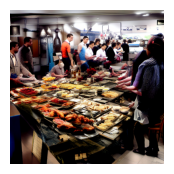

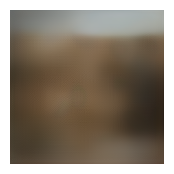

 10%|█         | 1/10 [00:07<01:03,  7.11s/it]

final_subj01_pretrained_40sess_24bs


sampling loop time step:   0%|          | 0/19 [00:00<?, ?it/s]

['a man standing next to a table.']


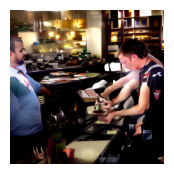

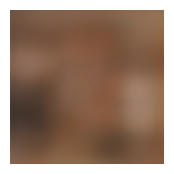

 20%|██        | 2/10 [00:11<00:44,  5.59s/it]

final_subj01_pretrained_40sess_24bs


sampling loop time step:   0%|          | 0/19 [00:00<?, ?it/s]

['a surfer riding a wave.']


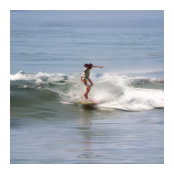

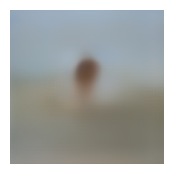

 30%|███       | 3/10 [00:16<00:35,  5.10s/it]

final_subj01_pretrained_40sess_24bs


sampling loop time step:   0%|          | 0/19 [00:00<?, ?it/s]

['a kite flying over a beach.']


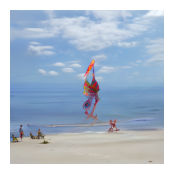

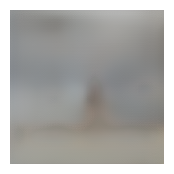

 40%|████      | 4/10 [00:20<00:29,  4.87s/it]

final_subj01_pretrained_40sess_24bs


sampling loop time step:   0%|          | 0/19 [00:00<?, ?it/s]

['a building with a clock on it.']


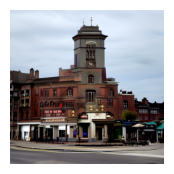

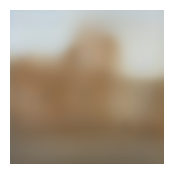

 50%|█████     | 5/10 [00:25<00:23,  4.74s/it]

final_subj01_pretrained_40sess_24bs


sampling loop time step:   0%|          | 0/19 [00:00<?, ?it/s]

['a plate of food']


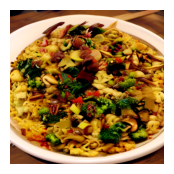

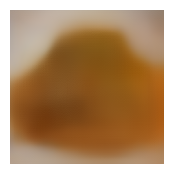

 60%|██████    | 6/10 [00:29<00:18,  4.66s/it]

final_subj01_pretrained_40sess_24bs


sampling loop time step:   0%|          | 0/19 [00:00<?, ?it/s]

['a plate of food']


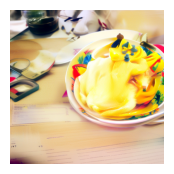

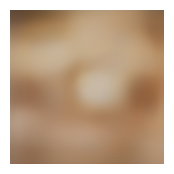

 70%|███████   | 7/10 [00:34<00:13,  4.61s/it]

final_subj01_pretrained_40sess_24bs


sampling loop time step:   0%|          | 0/19 [00:00<?, ?it/s]

['a group of people playing a game of frisbee.']


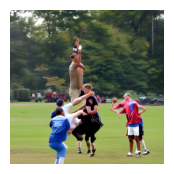

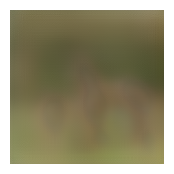

 80%|████████  | 8/10 [00:38<00:09,  4.58s/it]

final_subj01_pretrained_40sess_24bs


sampling loop time step:   0%|          | 0/19 [00:00<?, ?it/s]

['a cat sitting on top of a table.']


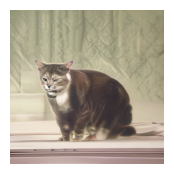

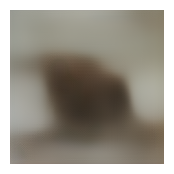

 90%|█████████ | 9/10 [00:43<00:04,  4.56s/it]

final_subj01_pretrained_40sess_24bs


sampling loop time step:   0%|          | 0/19 [00:00<?, ?it/s]

['a surfer is riding a wave.']


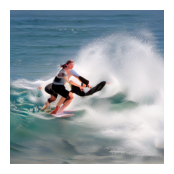

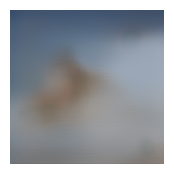

100%|██████████| 10/10 [00:47<00:00,  4.78s/it]

final_subj01_pretrained_40sess_24bs
torch.Size([10, 3, 256, 256])


saved final_subj01_pretrained_40sess_24bs outputs!


In [ ]:
import xformers
# get all reconstructions
model.to(device)
model.eval().requires_grad_(False)

# all_images = None
all_blurryrecons = None
all_recons = None
all_predcaptions = []
all_clipvoxels = None

minibatch_size = 1
num_samples_per_image = 1
assert num_samples_per_image == 1


if utils.is_interactive(): plotting=True

# --------------------------------------

# --- PATCH 1 to avoid errors of memory
def native_sdpa(query, key, value, *args, **kwargs):
    # Spostiamo l'import direttamente QUI DENTRO per sicurezza assoluta
    import torch.nn.functional as F 
    
    needs_transpose = query.dim() == 4
    if needs_transpose:
        query, key, value = query.transpose(1, 2), key.transpose(1, 2), value.transpose(1, 2)
    
    out = F.scaled_dot_product_attention(query, key, value)
    
    if needs_transpose:
        out = out.transpose(1, 2)
    return out

xformers.ops.memory_efficient_attention = native_sdpa
# -------------------------------------------------

# --- PATCH 2: Correction to visualize images avoiding errors

if hasattr(diffusion_engine, 'first_stage_model'):
    diffusion_engine.first_stage_model.to(dtype=torch.float32)

original_decode = diffusion_engine.decode_first_stage

def safe_decode(z, *args, **kwargs):
    with torch.cuda.amp.autocast(enabled=False):
        return original_decode(z.to(torch.float32), *args, **kwargs)

diffusion_engine.decode_first_stage = safe_decode
# ----------------------------------------------------------------
# --------------------------------------

with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.float16):
    # for batch in tqdm(range(0,len(np.unique(test_images_idx)),minibatch_size)): # this is for all images
    for batch in tqdm(range(0,10)): # to choose how many images we want to output 

        uniq_imgs = np.unique(test_images_idx)[batch:batch+minibatch_size]
        voxel = None
        for uniq_img in uniq_imgs:
            locs = np.where(test_images_idx==uniq_img)[0]
            if len(locs)==1:
                locs = locs.repeat(3)
            elif len(locs)==2:
                locs = locs.repeat(2)[:3]
            assert len(locs)==3
            if voxel is None:
                voxel = test_voxels[None,locs] # 1, num_image_repetitions, num_voxels
            else:
                voxel = torch.vstack((voxel, test_voxels[None,locs]))
        voxel = voxel.to(device)
        
        for rep in range(3):
            voxel_ridge = model.ridge(voxel[:,[rep]],0) # 0th index of subj_list
            backbone0, clip_voxels0, blurry_image_enc0 = model.backbone(voxel_ridge)
            if rep==0:
                clip_voxels = clip_voxels0
                backbone = backbone0
                blurry_image_enc = blurry_image_enc0[0]
            else:
                clip_voxels += clip_voxels0
                backbone += backbone0
                blurry_image_enc += blurry_image_enc0[0]
        clip_voxels /= 3
        backbone /= 3
        blurry_image_enc /= 3
                
        # Save retrieval submodule outputs
        if all_clipvoxels is None:
            all_clipvoxels = clip_voxels.cpu()
        else:
            all_clipvoxels = torch.vstack((all_clipvoxels, clip_voxels.cpu()))
        
        # Feed voxels through OpenCLIP-bigG diffusion prior
        prior_out = model.diffusion_prior.p_sample_loop(backbone.shape, 
                        text_cond = dict(text_embed = backbone), 
                        cond_scale = 1., timesteps = 20)
        
        pred_caption_emb = clip_convert(prior_out)
        generated_ids = clip_text_model.generate(pixel_values=pred_caption_emb, max_length=20)
        generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)
        all_predcaptions = np.hstack((all_predcaptions, generated_caption))
        print(generated_caption)
        
        # Feed diffusion prior outputs through unCLIP
        for i in range(len(voxel)):
            samples = utils.unclip_recon(prior_out[[i]],
                             diffusion_engine,
                             vector_suffix,
                             num_samples=num_samples_per_image)
            if all_recons is None:
                all_recons = samples.cpu()
            else:
                all_recons = torch.vstack((all_recons, samples.cpu()))
            if plotting:
                for s in range(num_samples_per_image):
                    plt.figure(figsize=(2,2))
                    plt.imshow(transforms.ToPILImage()(samples[s]))
                    plt.axis('off')
                    plt.show()

        if blurry_recon:
            blurred_image = (autoenc.decode(blurry_image_enc/0.18215).sample/ 2 + 0.5).clamp(0,1)
            
            for i in range(len(voxel)):
                im = torch.Tensor(blurred_image[i])
                if all_blurryrecons is None:
                    all_blurryrecons = im[None].cpu()
                else:
                    all_blurryrecons = torch.vstack((all_blurryrecons, im[None].cpu()))
                if plotting:
                    plt.figure(figsize=(2,2))
                    plt.imshow(transforms.ToPILImage()(im))
                    plt.axis('off')
                    plt.show()

        if plotting: 
            print(model_name)
            # break # dont actually want to run the whole thing with plotting=True. Uncomment if you want to visualize just one image

# resize outputs before saving
imsize = 256
all_recons = transforms.Resize((imsize,imsize))(all_recons).float()
if blurry_recon: 
    all_blurryrecons = transforms.Resize((imsize,imsize))(all_blurryrecons).float()
        
# saving
print(all_recons.shape)
# # You can find the all_images file on huggingface: https://huggingface.co/datasets/pscotti/mindeyev2/tree/main/evals
# torch.save(all_images,"evals/all_images.pt") 
if blurry_recon:
    torch.save(all_blurryrecons,f"evals/{model_name}/{model_name}_all_blurryrecons.pt")
torch.save(all_recons,f"evals/{model_name}/{model_name}_all_recons.pt")
torch.save(all_predcaptions,f"evals/{model_name}/{model_name}_all_predcaptions.pt")
torch.save(all_clipvoxels,f"evals/{model_name}/{model_name}_all_clipvoxels.pt")
print(f"saved {model_name} outputs!")

if not utils.is_interactive():
    sys.exit(0)